#Simple one

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [5]:
df = pd.read_csv('/content/drive/MyDrive/DS Data/kmeans_employee_dirty_dataset.csv')

df.head()



,Employee_ID,Experience_Years,Age,Department,Salary,Employees
0,81,8.2,NaN,Finance,95000.0,43.0
1,143,1.2,NaN,NaN,61700.0,84.0
2,77,5.5,31.0,IT,94300.0,51.0
3,156,10.0,45.0,Management,180900.0,19.0
4,87,7.1,37.0,Finance,86100.0,29.0


Dataset Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       180 non-null    int64  
 1   Experience_Years  174 non-null    float64
 2   Age               175 non-null    float64
 3   Department        177 non-null    object 
 4   Salary            174 non-null    float64
 5   Employees         176 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 8.6+ KB


In [8]:
df.describe()

,Employee_ID,Experience_Years,Age,Salary,Employees
count,180.000000,174.000000,175.000000,174.000000,176.000000
mean,85.883333,5.868391,32.051429,82829.885057,41.153409
std,49.122953,3.334403,7.396231,37034.700538,21.051075
min,1.000000,0.300000,20.000000,22200.000000,8.000000
25%,44.750000,3.225000,26.000000,53950.000000,20.000000
50%,85.500000,5.250000,31.000000,80400.000000,39.000000
75%,127.250000,7.950000,37.000000,105050.000000,59.000000
max,172.000000,16.000000,52.000000,194900.000000,89.000000


Missing Values

In [10]:
df.isnull().sum()

,0
Employee_ID,0
Experience_Years,6
Age,5
Department,3
Salary,6
Employees,4


##Fill Missing Values

Numerical

In [12]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    df[col] = df[col].fillna(df[col].mean())

Categorical

In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:

    df[col] = df[col].fillna(df[col].mode()[0])

##Encode Categorical Data

In [14]:
le = LabelEncoder()

for col in cat_cols:

    df[col] = le.fit_transform(df[col])

##EDA
Histograms

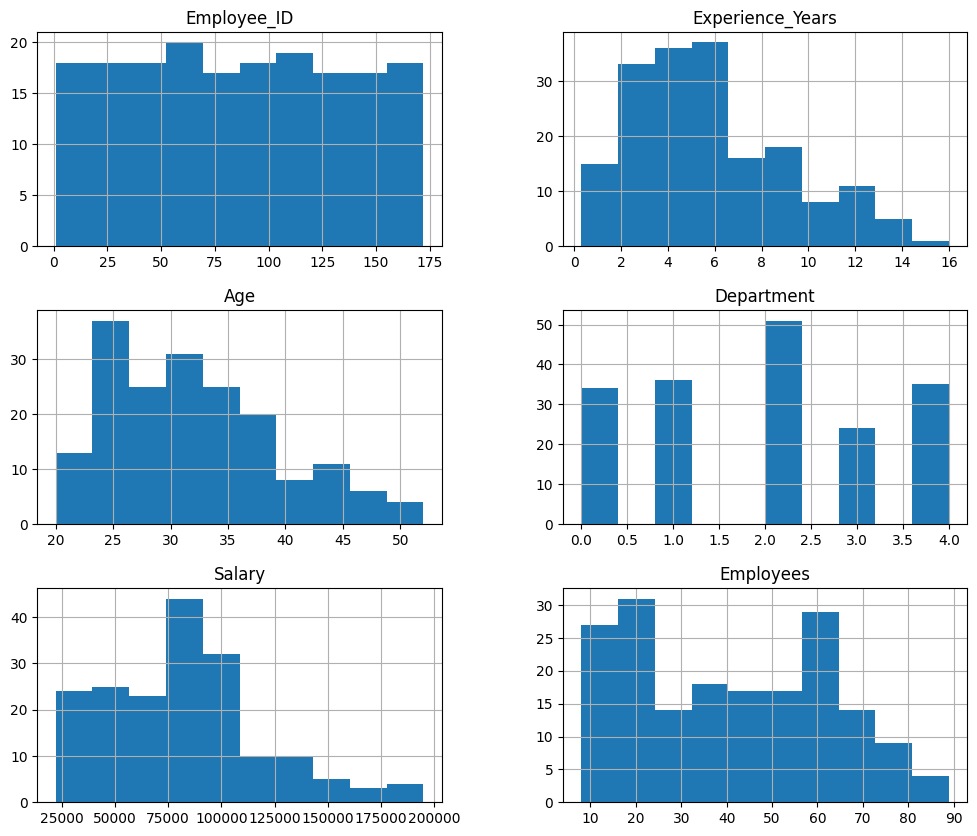

In [15]:
df.hist(figsize=(12,10))

plt.show()

Scatter Plot

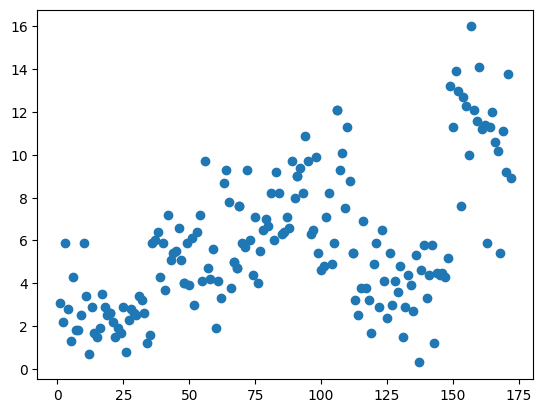

In [16]:
plt.scatter(df.iloc[:,0], df.iloc[:,1])

plt.show()

Bar Chart

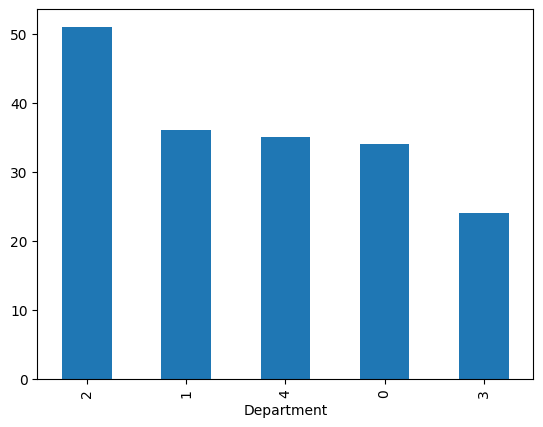

In [20]:
df['Department'].value_counts().plot(kind='bar')

plt.show()

Pie Chart

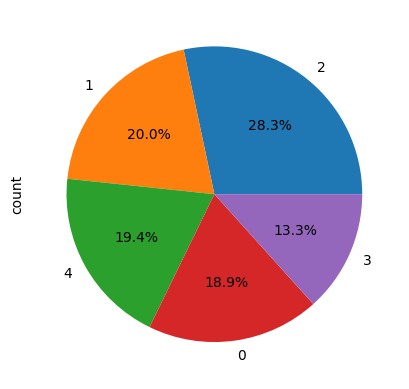

In [21]:
df['Department'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

##Scale Data

KMeans works better after scaling

In [23]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

##Elbow Method

In [31]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

print(kmeans.cluster_centers_)

[[-0.54675139 -0.04742324 -0.11955191  0.04069616  0.01055735  0.62773451]
 [ 0.91079868 -0.59137423 -0.56457687  1.46506181 -0.51831728  1.30832389]
 [ 0.2305366   0.62750539  0.73329189 -1.42436564  0.57510791 -0.31749231]
 [-1.3846272  -1.0224675  -1.00023856 -0.69183474 -1.21818157 -1.05123353]
 [ 1.52321467  1.63059505  1.55745945  0.77322706  1.76801758 -1.24363499]]


Plot Elbow Method

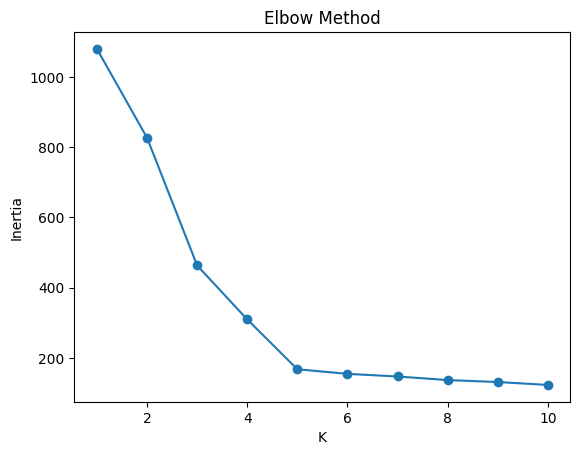

In [32]:
plt.plot(K, inertia, marker='o')

plt.xlabel('K')

plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.show()

##Train Final KMeans

In [33]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

kmeans.fit(scaled_data)

clusters = kmeans.labels_

##Add Cluster Column

In [34]:
df['Cluster'] = clusters

df.head()

,Employee_ID,Experience_Years,Age,Department,Salary,Employees,Cluster
0,81,8.2,32.051429,0,95000.0,43.0,2
1,143,1.2,32.051429,2,61700.0,84.0,1
2,77,5.5,31.000000,2,94300.0,51.0,0
3,156,10.0,45.000000,3,180900.0,19.0,4
4,87,7.1,37.000000,0,86100.0,29.0,2


##Visualize Clusters

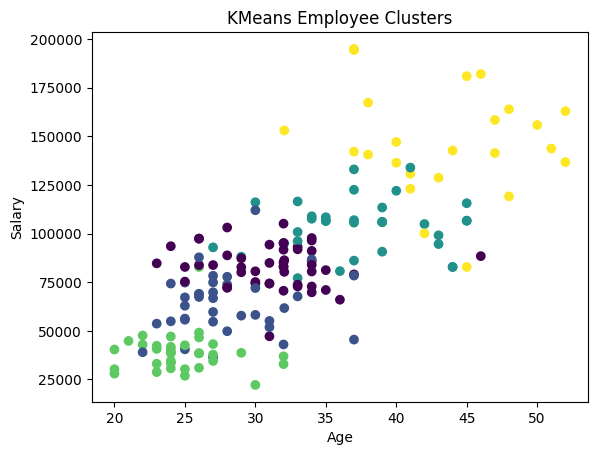

In [42]:
plt.scatter(
    df['Age'],
    df['Salary'],
    c=clusters
)

plt.xlabel('Age')

plt.ylabel('Salary')

plt.title('KMeans Employee Clusters')

plt.show()

Cluster Analysis

In [43]:
df.groupby('Cluster').mean()

,Employee_ID,Experience_Years,Age,Department,Salary,Employees
Cluster,,,,,,
0,59.100000,5.713368,31.182057,2.000000,83213.195402,54.183068
1,130.500000,3.935233,27.945873,3.944444,64011.111111,68.309817
2,97.176471,7.919659,37.383866,0.000000,103710.581474,34.563336
3,18.055556,2.526022,24.777778,1.000000,38600.830140,19.333333
4,160.500000,11.198683,43.377143,3.000000,147022.078544,15.339725
